In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# DATASET1 (Healthcare attrition)

In [ ]:
df=pd.read_csv("EmployeeArt/dataset5_all.csv")
# df=df.drop(columns=["EmployeeID"])
# df["Emp_ID"].value_counts()

In [11]:
df.columns

Index(['stag', 'event', 'gender', 'age', 'industry', 'profession', 'traffic',
       'coach', 'head_gender', 'greywage', 'way', 'extraversion', 'independ',
       'selfcontrol', 'anxiety', 'novator'],
      dtype='object')

In [12]:
df.dtypes

stag            float64
event             int64
gender           object
age             float64
industry         object
profession       object
traffic          object
coach            object
head_gender      object
greywage         object
way              object
extraversion    float64
independ        float64
selfcontrol     float64
anxiety         float64
novator         float64
dtype: object

In [13]:
# df["City"].value_counts()

## EDA


In [15]:
df.dtypes

stag            float64
event             int64
gender           object
age             float64
industry         object
profession       object
traffic          object
coach            object
head_gender      object
greywage         object
way              object
extraversion    float64
independ        float64
selfcontrol     float64
anxiety         float64
novator         float64
dtype: object

In [16]:
df.columns.shape

(16,)

In [17]:
col = df["event"]
df = df.drop("event", axis=1)
df["event"] = col

In [18]:
df.columns

Index(['stag', 'gender', 'age', 'industry', 'profession', 'traffic', 'coach',
       'head_gender', 'greywage', 'way', 'extraversion', 'independ',
       'selfcontrol', 'anxiety', 'novator', 'event'],
      dtype='object')

In [ ]:
df["event"]=df["event"].astype('object')
df.dtypes

stag             float64
gender          category
age              float64
industry        category
profession      category
traffic         category
coach           category
head_gender     category
greywage        category
way             category
extraversion     float64
independ         float64
selfcontrol      float64
anxiety          float64
novator          float64
event             object
dtype: object

In [25]:

CategoricalCols=np.zeros(len(df.columns))
NumericCols=np.zeros(len(df.columns))

CategoricalColsIndex=[] # index from 0
NumericColsIndex=[]
for i, (col, dtype) in enumerate(zip(df.columns, df.dtypes)):
    if dtype=="object":
        CategoricalCols[i]=1
        CategoricalColsIndex.append(i)
        df[col] = df[col].astype('category')
    else:
        NumericCols[i]=1
        NumericColsIndex.append(i)


In [27]:
df.dtypes

stag             float64
gender          category
age              float64
industry        category
profession      category
traffic         category
coach           category
head_gender     category
greywage        category
way             category
extraversion     float64
independ         float64
selfcontrol      float64
anxiety          float64
novator          float64
event           category
dtype: object

In [28]:
df.shape

(1129, 16)

In [ ]:
# NumericCols
# print(NumericColsIndex)

In [29]:
df.event

0       1
1       1
2       1
3       1
4       1
       ..
1124    0
1125    0
1126    0
1127    0
1128    0
Name: event, Length: 1129, dtype: category
Categories (2, int64): [0, 1]

In [30]:
# df["LeftCompany"] = df["LeftCompany"].map({"No": 0, "Yes": 1})


In [31]:
# df.columns
corrmatrix=df.corr(numeric_only=True)
corrmatrix.head(23)

,stag,age,extraversion,independ,selfcontrol,anxiety,novator
stag,1.000000,-0.197381,-0.088227,0.000550,0.077076,0.014755,-0.037633
age,-0.197381,1.000000,-0.149753,0.056129,0.038996,0.057782,0.039509
extraversion,-0.088227,-0.149753,1.000000,-0.200052,-0.538039,-0.135046,0.297375
independ,0.000550,0.056129,-0.200052,1.000000,-0.165795,-0.427209,0.023865
selfcontrol,0.077076,0.038996,-0.538039,-0.165795,1.000000,-0.107568,-0.565972
anxiety,0.014755,0.057782,-0.135046,-0.427209,-0.107568,1.000000,0.246668
novator,-0.037633,0.039509,0.297375,0.023865,-0.565972,0.246668,1.000000


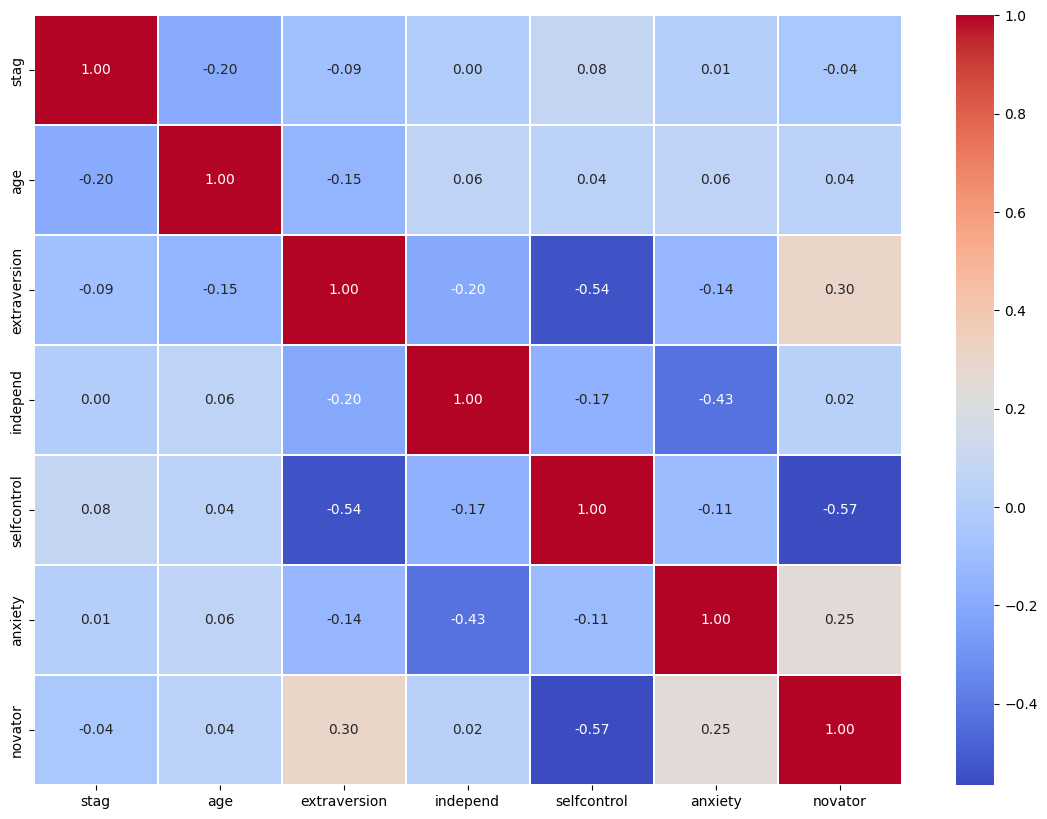

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))  
sns.heatmap(corrmatrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.1)
plt.show()


In [ ]:
# high corellation between performance rating and salary hike
# job level nad years of working

In [33]:
categorical_df = df.select_dtypes(include=['category'])
categorical_df

,gender,industry,profession,traffic,coach,head_gender,greywage,way,event
0,m,Banks,HR,rabrecNErab,no,f,white,bus,1
1,m,Banks,HR,empjs,no,m,white,bus,1
2,f,PowerGeneration,HR,rabrecNErab,no,m,white,bus,1
3,f,PowerGeneration,HR,rabrecNErab,no,m,white,bus,1
4,m,Retail,Commercial,youjs,yes,f,white,bus,1
...,...,...,...,...,...,...,...,...,...
1124,f,Banks,HR,rabrecNErab,my head,m,white,bus,0
1125,f,Banks,HR,rabrecNErab,my head,m,white,bus,0
1126,f,Telecom,Accounting,KA,no,f,white,bus,0
1127,f,Consult,HR,empjs,no,m,grey,bus,0


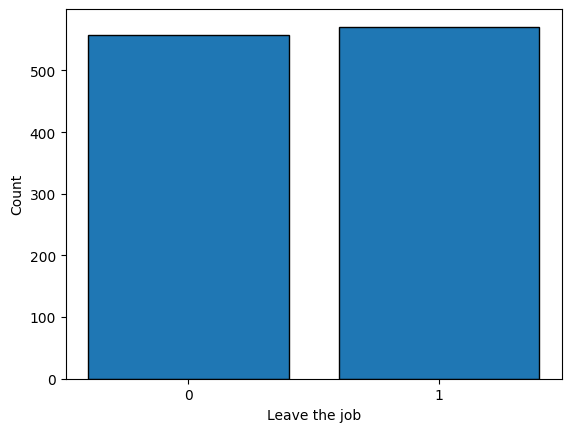

In [35]:
counts = df["event"].value_counts().sort_index()

plt.bar(counts.index, counts.values, edgecolor='black')
plt.xticks(counts.index) # imp
plt.xlabel("Leave the job")
plt.ylabel("Count")
plt.show()

In [36]:
non_categorical_cols = df.select_dtypes(include=['number']).columns

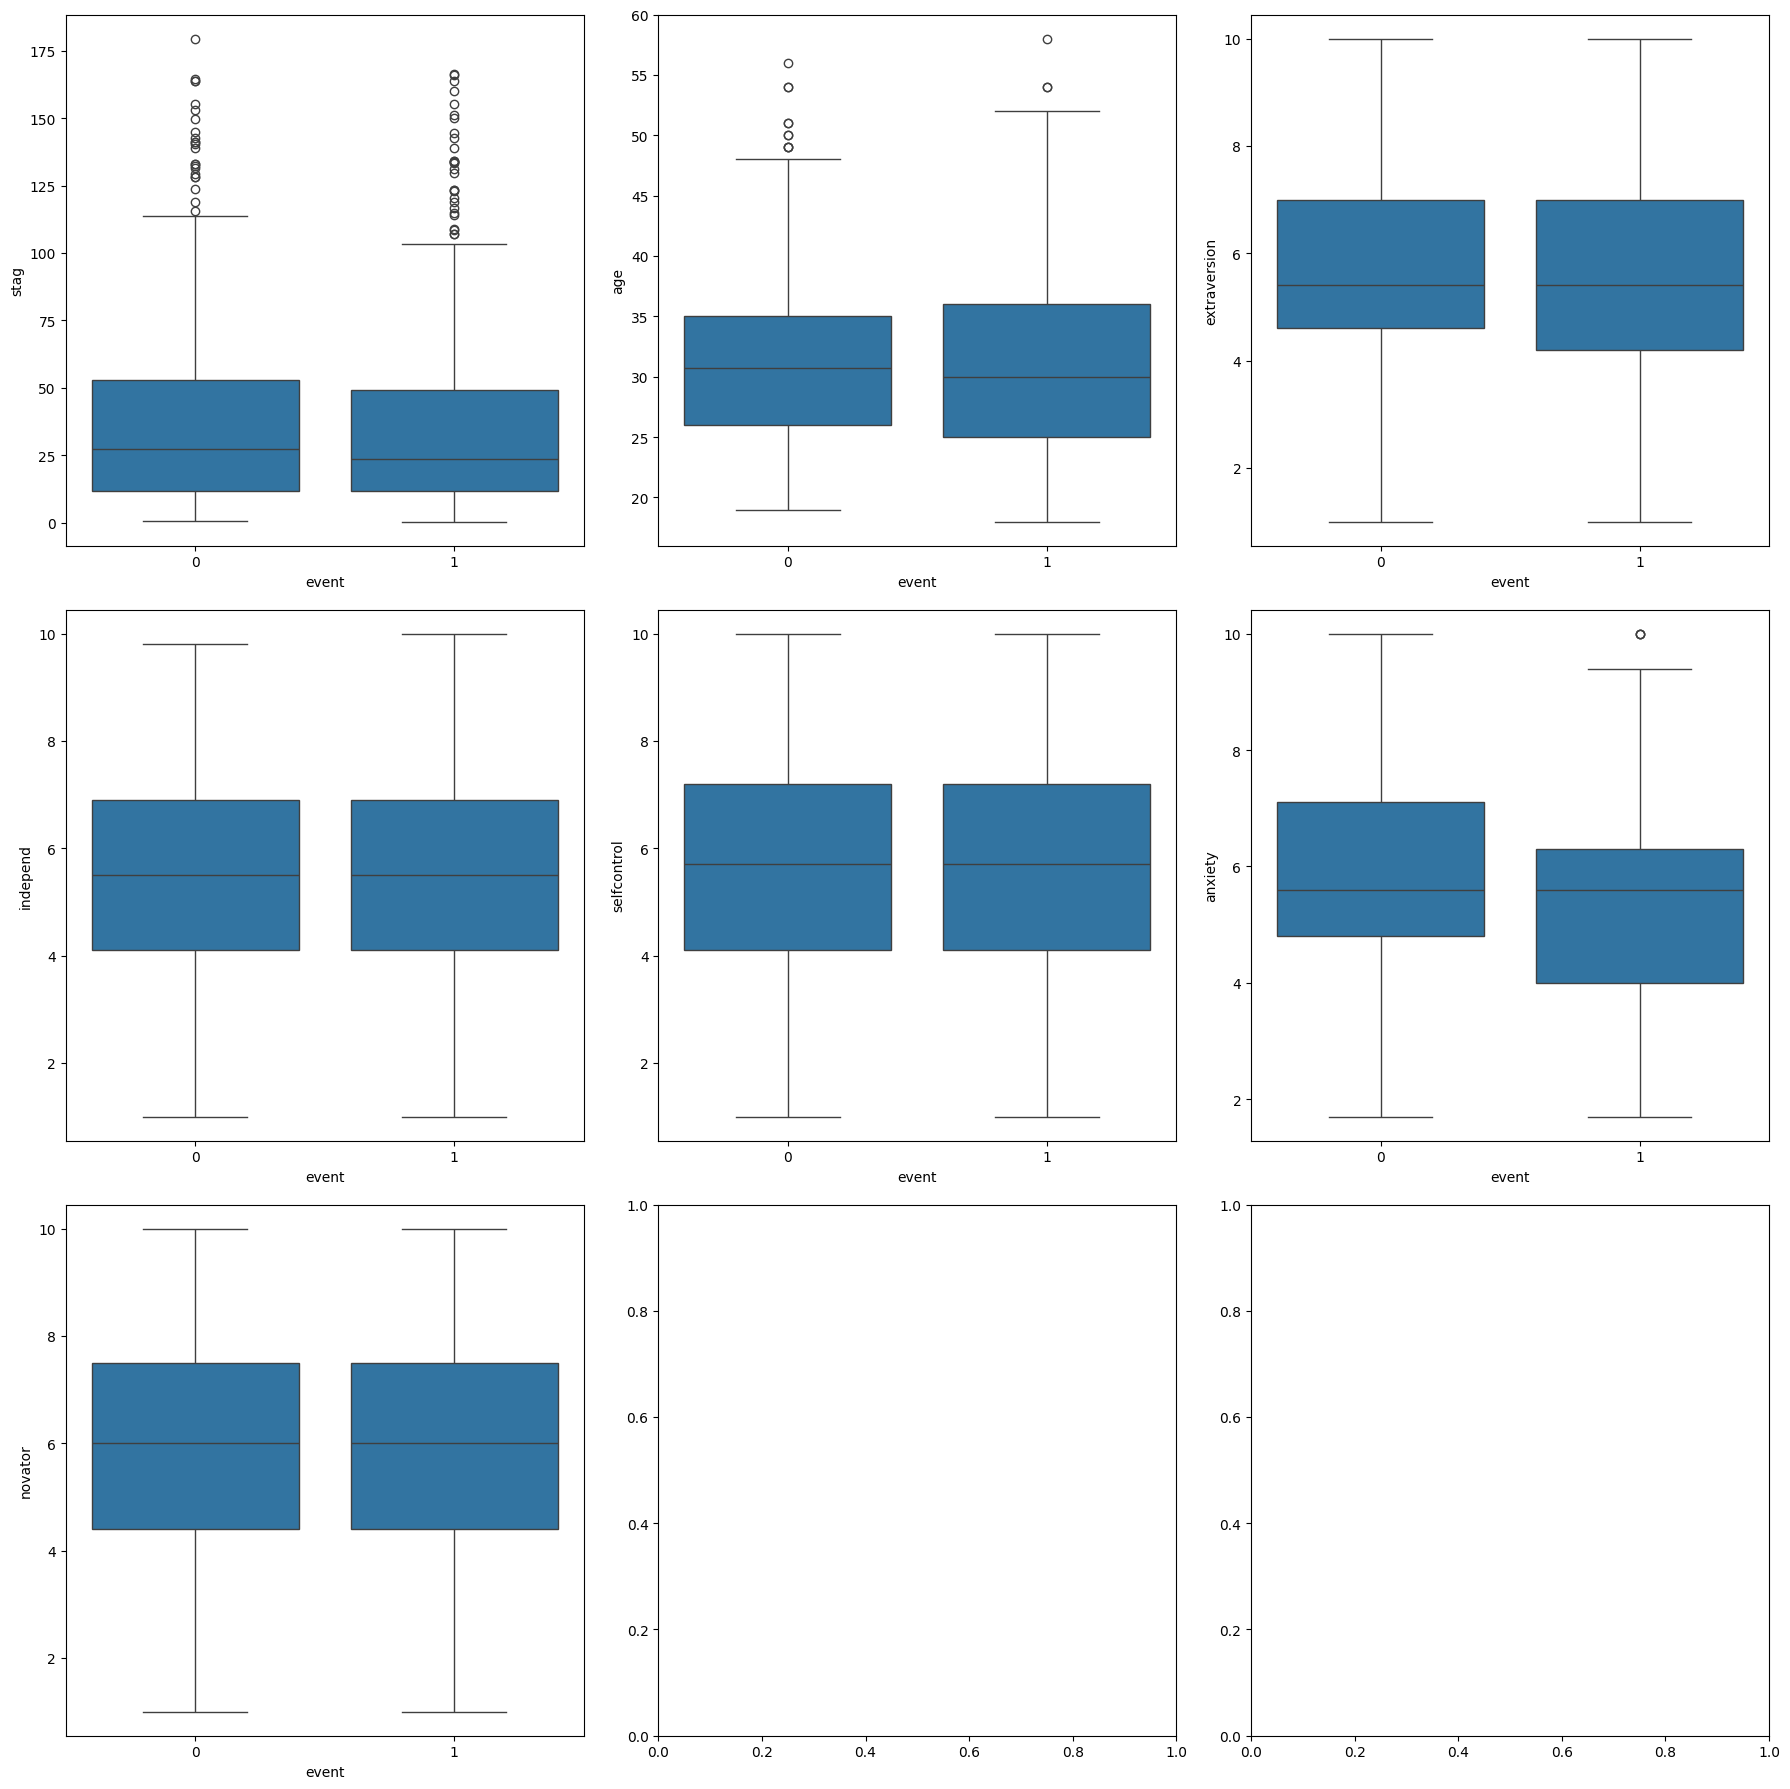

In [38]:
import math

total_plots = len(non_categorical_cols) 
cols = 3
rows = math.ceil(total_plots / cols)

fig_width = cols * 6
fig_height = rows * 6

fig, axes = plt.subplots(
    nrows=rows,
    ncols=cols,
    figsize=(fig_width, fig_height),
    # constrained_layout=True
)
row,col=0,0
for i in df.columns:
    if df[i].dtype!="category":
        sns.boxplot(ax=axes[row,col],x=df['event'],y=df[i])
        col=col+1
        if(col==3):
            row+=1
        col=(col)%cols

plt.tight_layout(w_pad=2)
plt.show()

In [39]:
df.dtypes

stag             float64
gender          category
age              float64
industry        category
profession      category
traffic         category
coach           category
head_gender     category
greywage        category
way             category
extraversion     float64
independ         float64
selfcontrol      float64
anxiety          float64
novator          float64
event           category
dtype: object

In [ ]:
# df[""].value_counts()

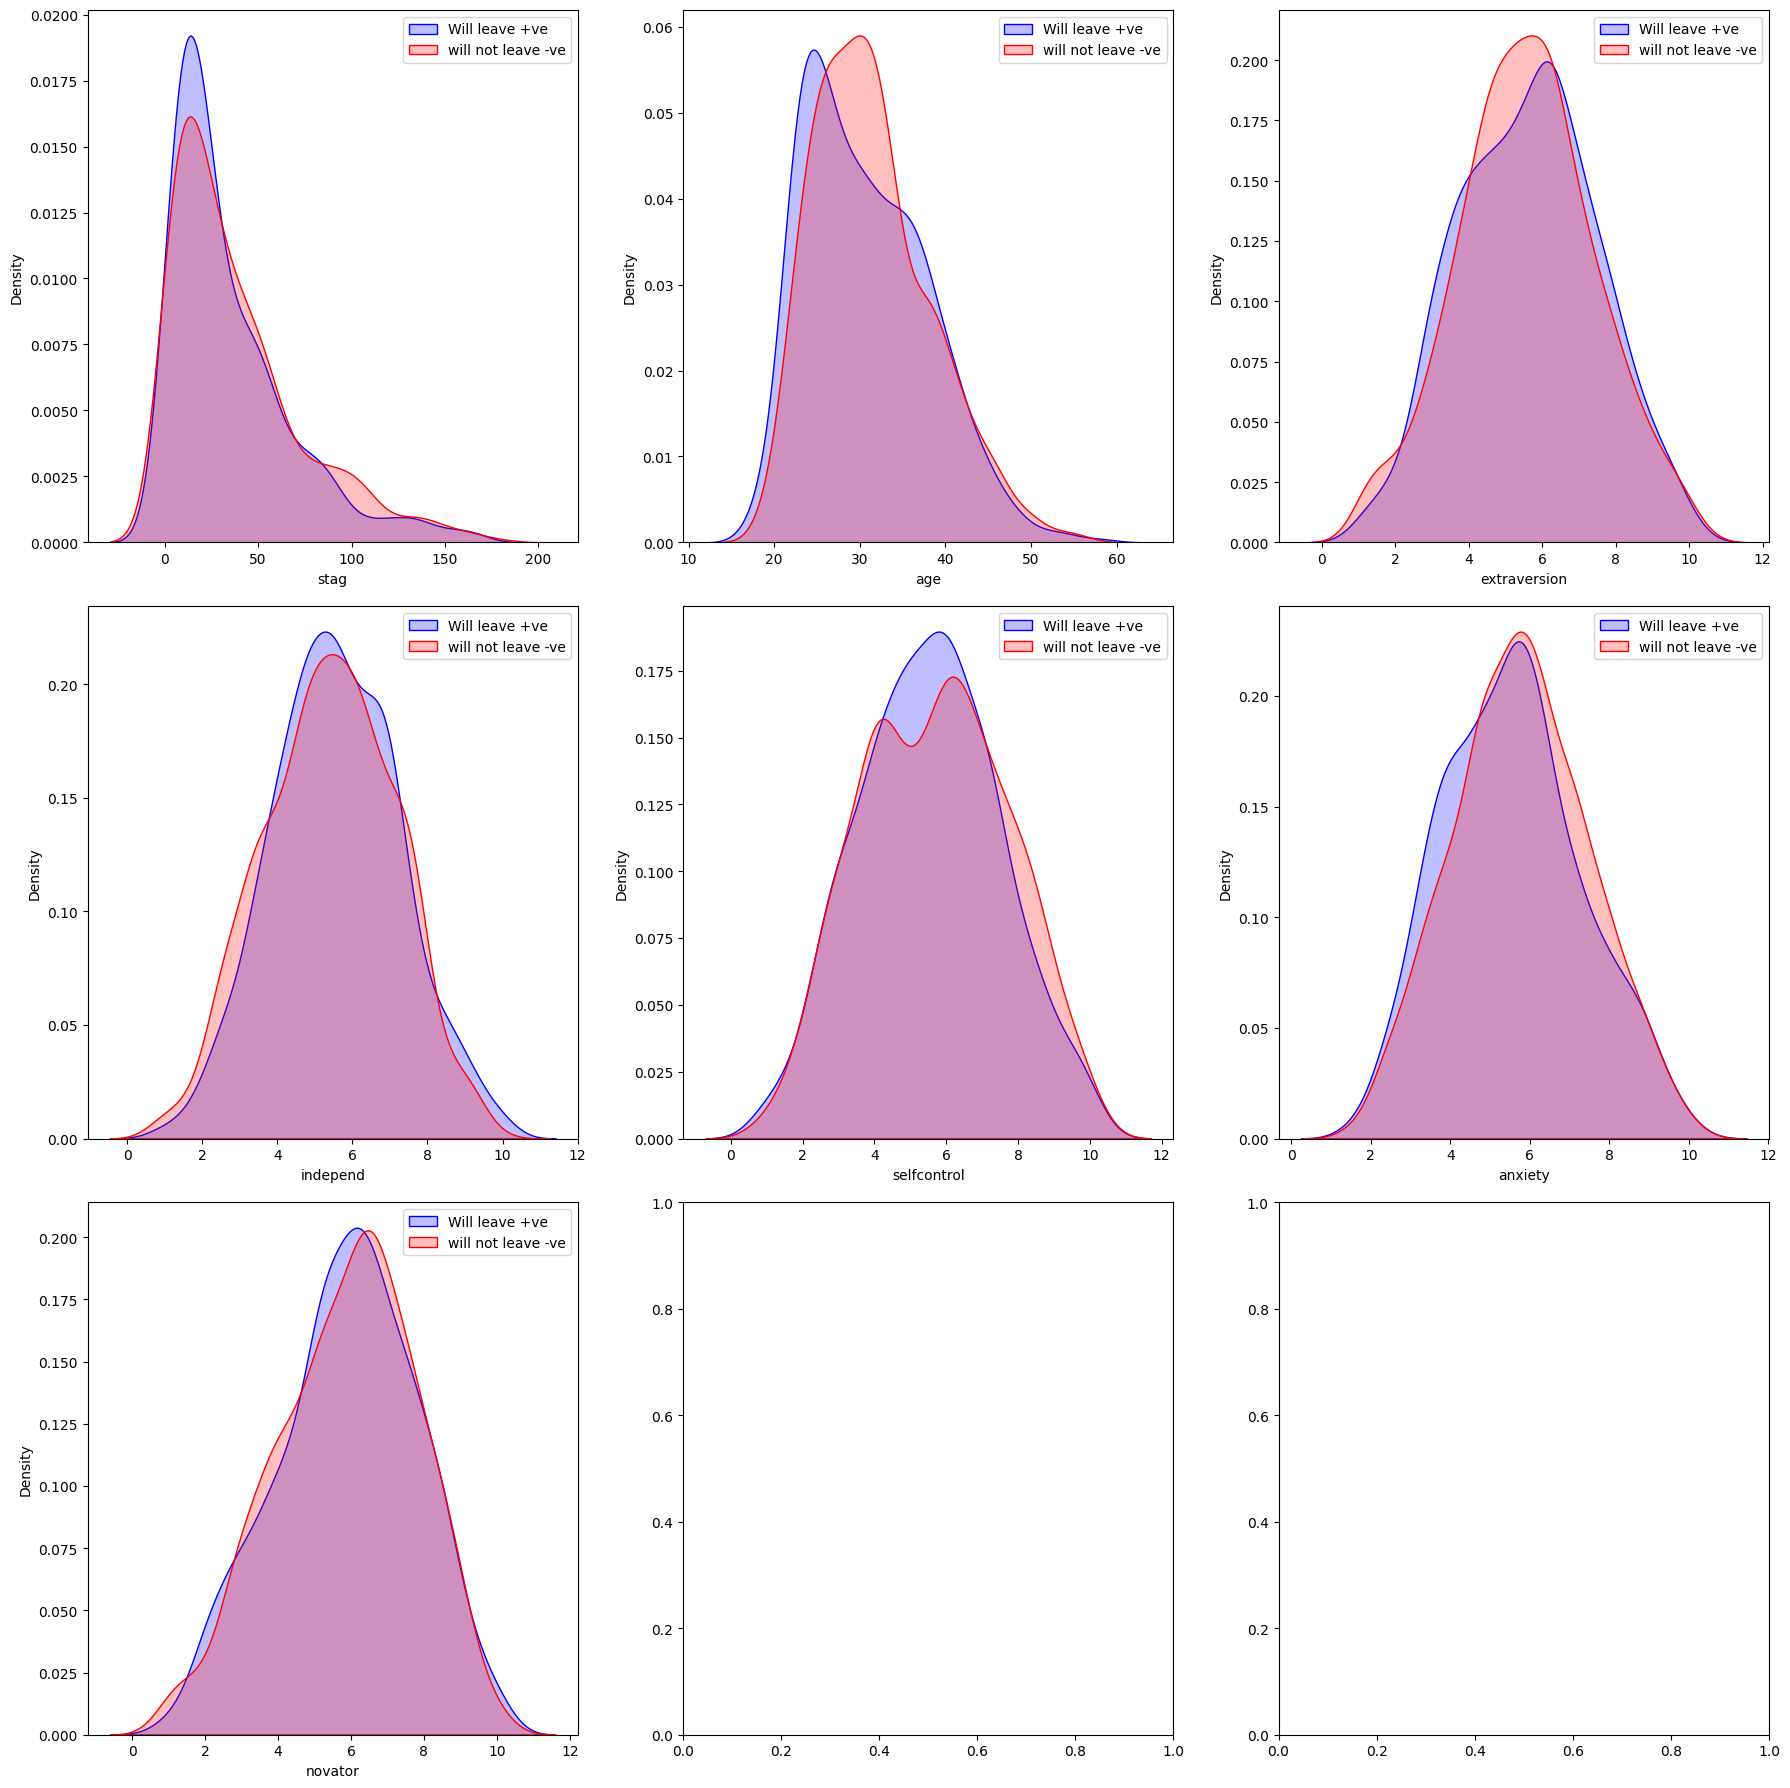

In [41]:

total_plots = len(non_categorical_cols) 
cols = 3
rows = math.ceil(total_plots / cols)

fig_width = cols * 6
fig_height = rows * 6

fig, axes = plt.subplots(
    nrows=rows,
    ncols=cols,
    figsize=(fig_width, fig_height),
    # constrained_layout=True
)
row,col=0,0

for i in df.columns:
    if df[i].dtype!="category":
        
        sns.kdeplot(
            df[df["event"]==1][i],
            color='blue', label='Will leave +ve',
            ax=axes[row,col],
            fill=True
            )
        
        sns.kdeplot(
            df[df["event"]==0][i],
            color='red', 
            label='will not leave -ve',
            ax=axes[row,col],
            fill=True
            )
        
        axes[row, col].legend()
        col=col+1
        if(col==3):
            row+=1
        col=(col)%cols

plt.tight_layout(w_pad=2)
plt.show()





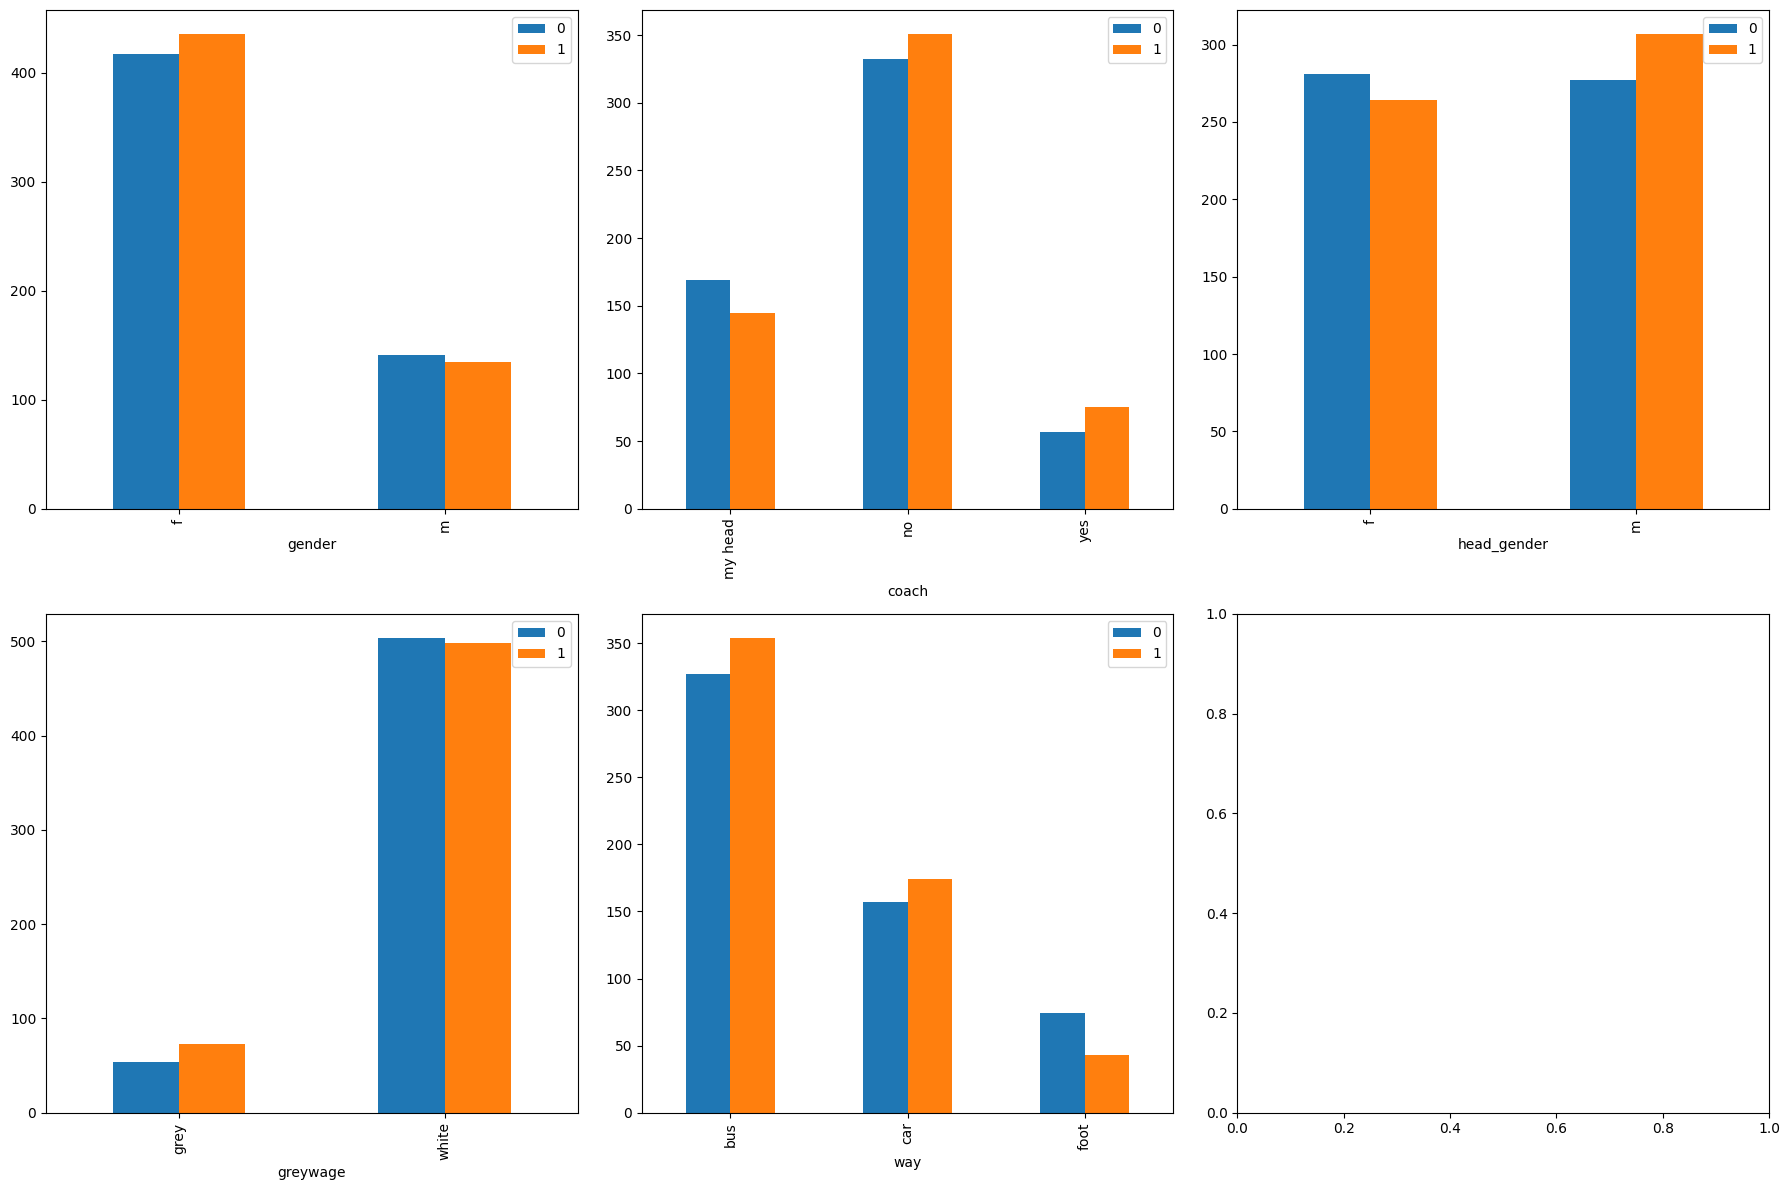

In [43]:
count=0
collist=[]
for i in df.columns:
    if len(df[i].value_counts())<=7:
        count+=1
        collist.append(i)
total_plots = count-1 
cols = 3
rows = math.ceil(total_plots / cols)

fig_width = cols * 6
fig_height = rows * 6

fig, axes = plt.subplots(
    nrows=rows,
    ncols=cols,
    figsize=(fig_width, fig_height),
    # constrained_layout=True
)
row,col=0,0

for i in df.columns:
    if i != "event" and len(df[i].value_counts())<=7:
        crosstb = pd.crosstab(df[i], df["event"])
        crosstb.plot(kind="bar",ax=axes[row,col])
        axes[row, col].legend()
        col=col+1
        if(col==3):
            row+=1
        col=(col)%cols


plt.tight_layout(w_pad=2)
plt.show()

In [ ]:
X = df.drop(columns=['event'])

y = df['event']
# categorical=[2,5]
# binarize_categorical=[1 if i in categorical else 0 for i in range(10)]
cat_cols=[1 if df[i].dtype=="category" else 0 for i in X.columns]
Num_cols=[int(not(i)) for i in cat_cols]
# X.head()
X.dtypes


In [ ]:
print(cat_cols)
print(Num_cols)

In [ ]:
from Model import Binclassification
Binaryclassobj=Binclassification(X,y,Num_cols,cat_cols)
Binaryclassobj.simulate_ntimes(n=5,EncodeCat=True,sampling=2)

In [ ]:
results_n=Binaryclassobj.simulation_result_n
results_n.keys()

In [ ]:
LR_N=[]
SVC_N=[]
DT_N=[]
RF_N=[]
ADA_N=[]
for i in results_n.keys():
    LR_N.append(results_n[i]["LogisticRegression"]["test_result"])
    SVC_N.append(results_n[i]["SVC"]["test_result"])
    DT_N.append(results_n[i]["DecisionTree"]["test_result"])
    RF_N.append(results_n[i]["RandomForest"]["test_result"])
    ADA_N.append(results_n[i]["AdaBoost"]["test_result"])


def summarize_results(Result_n):
    summary = {}
    
    keys = Result_n[0].keys()
    
    for key in keys:
        values = [float(dict[key]) for dict in Result_n]
        summary[key] = [
            np.mean(values),
            np.std(values)
        ]
    
    return summary


In [ ]:
LR_N_Results = summarize_results(LR_N)
SVC_N_Results = summarize_results(SVC_N)
DT_N_Results = summarize_results(DT_N)
RF_N_Results = summarize_results(RF_N)
ADA_N_Results = summarize_results(ADA_N)
